# Wikipedia Stability & Contention — English Pilot Study
### IS-618 · Social Media Data Analysis · University of Mannheim
*Marmee Pandya · Yuqing Mao · Selma Nezihoglu · Derya Demir Sechkin*

---

## What this notebook does

This is a **small-scale pilot** to validate the research design before running the full 800-article collection.

**Pipeline:**
1. Collect ~50 contested articles (POV/Neutrality templates, EN)
2. Collect candidate stable articles (no dispute history)
3. Match contested ↔ stable on: topic, article age, word count, Google Trends
4. Extract linguistic + structural features from matched pairs
5. Run a quick logistic regression to see if features discriminate
6. Validate labels using Talk Page signals (Mann-Whitney U)

**What we learn from the pilot:**
- Does the matching actually produce comparable pairs?
- Do linguistic features already show differences at small scale?
- Which features seem most promising?
- Are there data quality issues to fix before full collection?

---
> **Note on spaCy:** Run `pip install spacy && python -m spacy download en_core_web_sm` in your environment.  
> The notebook uses regex-based NLP as fallback so it runs even without the model.


## 0. Setup & Imports

In [1]:
# Run once if needed:
# !pip install requests pytrends lexicalrichness scikit-learn pandas numpy matplotlib seaborn spacy
# !python -m spacy download en_core_web_sm

import requests
import time
import json
import re
import random
import os
from datetime import datetime, timezone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import mannwhitneyu

# Try spaCy — fall back to regex if not available
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
    print("✅ spaCy loaded")
except Exception:
    SPACY_AVAILABLE = False
    print("⚠️  spaCy not available — using regex fallback (still works fine for pilot)")

try:
    from lexicalrichness import LexicalRichness
    LEXRICH_AVAILABLE = True
    print("✅ lexicalrichness loaded")
except Exception:
    LEXRICH_AVAILABLE = False
    print("⚠️  lexicalrichness not available — MTLD will be skipped")

try:
    from pytrends.request import TrendReq
    TRENDS_AVAILABLE = True
    print("✅ pytrends loaded")
except Exception:
    TRENDS_AVAILABLE = False
    print("⚠️  pytrends not available — Google Trends matching will be skipped")

HEADERS = {"User-Agent": "UniMannheim-SMDA-Pilot/1.0 (student research, uni-mannheim.de)"}
random.seed(42)
print("\n✅ All imports done")

✅ spaCy loaded
✅ lexicalrichness loaded
✅ pytrends loaded

✅ All imports done


## 1. Configuration

In [2]:
# ── Pilot scale ──────────────────────────────────────────────────
PILOT_CONTESTED    = 50    # contested articles to collect
PILOT_STABLE_POOL  = 300   # stable candidate pool (we'll match down to 50)
MIN_WORDS          = 1000  # minimum article length
MIN_EDITORS        = 10    # minimum unique editors
MIN_AGE_DAYS       = 365   # at least 1 year old

# ── Templates (language-level disputes only) ──────────────────────
EN_CONTESTED_TEMPLATES = ["Template:POV", "Template:Neutrality"]

# ── Date filter (template added 2022–2026) ────────────────────────
VALID_YEARS = [2022, 2023, 2024, 2025, 2026]

# ── Topic mapping (Wikipedia categories → 6 broad labels) ─────────
TOPIC_MAP = {
    "politics":  ["politics", "government", "election", "war", "military",
                  "conflict", "diplomacy", "politician", "president", "minister"],
    "science":   ["science", "biology", "physics", "chemistry", "mathematics",
                  "astronomy", "medicine", "health", "technology", "computing"],
    "history":   ["history", "historical", "ancient", "medieval", "century",
                  "empire", "revolution", "dynasty", "civilisation", "civilization"],
    "culture":   ["culture", "art", "music", "film", "literature", "religion",
                  "philosophy", "sport", "food", "architecture"],
    "people":    ["people", "born", "death", "biography", "actor", "musician",
                  "athlete", "author", "scientist", "politician"],
    "geography": ["geography", "country", "city", "region", "river", "mountain",
                  "island", "continent", "capital", "district"],
}

print("Config loaded")
print(f"  Target: {PILOT_CONTESTED} contested + {PILOT_CONTESTED} stable (matched)")
print(f"  Min words: {MIN_WORDS} | Min editors: {MIN_EDITORS} | Min age: {MIN_AGE_DAYS} days")


Config loaded
  Target: 50 contested + 50 stable (matched)
  Min words: 1000 | Min editors: 10 | Min age: 365 days


## 2. Helper Functions

In [3]:
def safe_get(url, params, retries=4, base_wait=3):
    """Robust Wikipedia API GET with retry and rate limit handling."""
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=20)
            if r.status_code == 429:
                print(f"    🚦 Rate limited — waiting 60s...")
                time.sleep(60)
                continue
            if r.status_code == 200 and r.text.strip():
                return r.json()
            time.sleep(base_wait * (attempt + 1))
        except Exception as e:
            time.sleep(base_wait * (attempt + 1))
    return None


def is_recent_dispute(text, valid_years=VALID_YEARS):
    """Check if a POV/Neutrality template was added in a valid year."""
    templates = re.findall(
        r'\{\{(?:POV|Neutrality)[^}]*\}\}', text, re.IGNORECASE
    )
    if not templates:
        return False
    for t in templates:
        m = re.search(r'date=\w+ (20\d{2})', t)
        if m and int(m.group(1)) in valid_years:
            return True
    return False


def clean_wikitext(text):
    """Strip Wikipedia markup — returns plain readable text."""
    text = re.sub(r'\{\{[^{}]*\}\}', '', text)           # templates
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]*)\]\]', r'\1', text)  # links
    text = re.sub(r'==+[^=]+=+', '', text)                 # headings
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>', '', text)                    # HTML
    text = re.sub(r"'{2,}", '', text)                      # bold/italic
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def get_topic(categories):
    """Map Wikipedia categories to one of 6 broad topic labels."""
    cats_lower = ' '.join(categories).lower()
    scores = {topic: 0 for topic in TOPIC_MAP}
    for topic, keywords in TOPIC_MAP.items():
        for kw in keywords:
            if kw in cats_lower:
                scores[topic] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'other'


def get_trends_score(title):
    """Fetch Google Trends 12-month average for a title. Returns None if unavailable."""
    if not TRENDS_AVAILABLE:
        return None
    try:
        pytrends = TrendReq(hl='en-US', tz=360)
        pytrends.build_payload([title], timeframe='today 12-m', geo='')
        df = pytrends.interest_over_time()
        if df.empty or title not in df.columns:
            return None
        return round(df[title].mean(), 1)
    except Exception:
        return None

print("✅ Helper functions defined")


✅ Helper functions defined


## 3. Collect Contested Articles

Fetch articles with active POV or Neutrality templates added 2022–2026.

In [4]:
def fetch_contested_titles(template, limit=500):
    """Fetch article titles embedding a given dispute template."""
    url = "https://en.wikipedia.org/w/api.php"
    titles = []
    params = {
        "action": "query", "list": "embeddedin",
        "eititle": template, "eilimit": 500,
        "einamespace": 0, "format": "json"
    }
    while len(titles) < limit:
        data = safe_get(url, params)
        if not data: break
        batch = data["query"]["embeddedin"]
        titles.extend([p["title"] for p in batch])
        if "continue" not in data: break
        params["eicontinue"] = data["continue"]["eicontinue"]
        time.sleep(1)
    return titles


def fetch_article(title, label):
    """Fetch full data for one article. Returns dict or None if rejected."""
    url = "https://en.wikipedia.org/w/api.php"

    # ── Main text ────────────────────────────────────────────
    d1 = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions|categories",
        "rvprop": "content|timestamp", "rvslots": "main",
        "rvlimit": 1, "cllimit": 50, "format": "json"
    })
    if not d1: return None
    page = list(d1["query"]["pages"].values())[0]
    if "revisions" not in page: return None

    raw_text  = page["revisions"][0]["slots"]["main"]["*"]
    word_count = len(raw_text.split())
    if word_count < MIN_WORDS: return None

    # Date filter for contested articles
    if label == 0 and not is_recent_dispute(raw_text):
        return None

    categories = [c["title"].replace("Category:", "")
                  for c in page.get("categories", [])]
    topic = get_topic(categories)

    clean_text = clean_wikitext(raw_text)
    citation_count = len(re.findall(r'<ref', raw_text, re.IGNORECASE))
    section_count  = len(re.findall(r'^==+[^=]', raw_text, re.MULTILINE))

    time.sleep(1.2)

    # ── Edit history ─────────────────────────────────────────
    d2 = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions", "rvprop": "user|timestamp",
        "rvlimit": 500, "format": "json"
    })
    revisions = []
    if d2:
        p2 = list(d2["query"]["pages"].values())[0]
        revisions = p2.get("revisions", [])

    unique_editors = len(set(rv.get("user","") for rv in revisions))
    total_edits    = len(revisions)
    if unique_editors < MIN_EDITORS: return None

    first_edit = revisions[-1]["timestamp"] if revisions else None
    if first_edit:
        age_days = (datetime.now(timezone.utc) -
                    datetime.fromisoformat(first_edit.replace("Z","+00:00"))).days
        if age_days < MIN_AGE_DAYS: return None
    else:
        age_days = 0

    # Edit recency ratio
    cutoff = datetime(2025, 10, 1, tzinfo=timezone.utc)
    recent = sum(1 for rv in revisions
                 if datetime.fromisoformat(
                     rv["timestamp"].replace("Z","+00:00")) >= cutoff)
    recency_ratio = round(recent / total_edits, 3) if total_edits > 0 else 0

    time.sleep(1.2)

    # ── Talk page ────────────────────────────────────────────
    d3 = safe_get(url, {
        "action": "query", "titles": f"Talk:{title}",
        "prop": "revisions", "rvprop": "comment|content|user",
        "rvslots": "main", "rvlimit": 500, "format": "json"
    })
    revert_count = 0
    talk_words   = 0
    talk_editors = 0
    if d3:
        tp = list(d3["query"]["pages"].values())[0]
        trevs = tp.get("revisions", [])
        revert_count = sum(1 for rv in trevs
                           if any(w in rv.get("comment","").lower()
                                  for w in ["revert","reverted","undid","undo","restored"]))
        talk_editors = len(set(rv.get("user","") for rv in trevs))
        if trevs and "slots" in trevs[0]:
            talk_words = len(trevs[0]["slots"]["main"].get("*","").split())

    return {
        "title":          title,
        "label":          label,
        "label_name":     "contested" if label == 0 else "stable",
        "raw_text":       raw_text,
        "clean_text":     clean_text,
        "word_count":     word_count,
        "topic":          topic,
        "citation_count": citation_count,
        "section_count":  section_count,
        "unique_editors": unique_editors,
        "total_edits":    total_edits,
        "age_days":       age_days,
        "recency_ratio":  recency_ratio,
        "revert_count":   revert_count,
        "talk_words":     talk_words,
        "talk_editors":   talk_editors,
        "collected_at":   datetime.now().isoformat(),
    }


In [5]:
# ── Fetch contested articles ───────────────────────────────────────
SAVE_FILE = "pilot_contested.json"
contested_articles = []

if os.path.exists(SAVE_FILE):
    with open(SAVE_FILE) as f:
        contested_articles = json.load(f)
    print(f"Loaded {len(contested_articles)} from {SAVE_FILE}")
else:
    seen = set()
    print("Fetching contested article titles...")
    
    all_titles = []
    for template in EN_CONTESTED_TEMPLATES:
        titles = fetch_contested_titles(template, limit=300)
        all_titles.extend(titles)
        print(f"  {template}: {len(titles)} titles")
    
    random.shuffle(all_titles)
    print(f"\nTotal candidates: {len(all_titles)} — collecting up to {PILOT_CONTESTED}...")
    
    for title in all_titles:
        if len(contested_articles) >= PILOT_CONTESTED: break
        if title in seen: continue
        
        time.sleep(random.uniform(2.5, 4.0))
        article = fetch_article(title, label=0)
        
        if article:
            contested_articles.append(article)
            seen.add(title)
            print(f"  [{len(contested_articles)}/{PILOT_CONTESTED}] ✅ {title} "
                  f"({article['word_count']} words, {article['age_days']} days, {article['topic']})")
        else:
            print(f"  ⊘ Skipped: {title}")
    
    with open(SAVE_FILE, "w") as f:
        json.dump(contested_articles, f, ensure_ascii=False, indent=2)
    print(f"\n✅ Saved {len(contested_articles)} contested articles")

print(f"\nContested articles: {len(contested_articles)}")


Loaded 50 from pilot_contested.json

Contested articles: 50


## 4. Collect Stable Candidate Pool

Collect a pool of stable articles — then match them to contested articles. Stable = no dispute template ever in revision history.

In [6]:
def has_ever_had_dispute_template(title):
    """
    Scan full revision history to check if a dispute template
    was ever present. Returns True if found (= article disqualified).
    Checks up to 500 revisions — sufficient for most articles.
    """
    url = "https://en.wikipedia.org/w/api.php"
    dispute_pattern = re.compile(
        r'\{\{(?:POV|Disputed|Neutrality|Biased|Unbalanced)', re.IGNORECASE
    )
    params = {
        "action": "query", "titles": title,
        "prop": "revisions", "rvprop": "content",
        "rvslots": "main", "rvlimit": 50,  # check last 50 revisions
        "format": "json"
    }
    data = safe_get(url, params)
    if not data: return False
    page = list(data["query"]["pages"].values())[0]
    for rv in page.get("revisions", []):
        content = rv.get("slots", {}).get("main", {}).get("*", "")
        if dispute_pattern.search(content):
            return True
    return False


def fetch_stable_candidates(n=300):
    """
    Fetch stable article candidates from Wikipedia Good Articles
    (broader and more diverse than Featured Articles alone).
    """
    url = "https://en.wikipedia.org/w/api.php"
    categories = [
        "Category:Featured_articles",
        "Category:Wikipedia_good_articles",
    ]
    all_titles = []
    for cat in categories:
        params = {
            "action": "query", "list": "categorymembers",
            "cmtitle": cat, "cmlimit": 500,
            "cmtype": "page", "format": "json"
        }
        while True:
            data = safe_get(url, params)
            if not data: break
            batch = data["query"]["categorymembers"]
            all_titles.extend([p["title"] for p in batch])
            if "continue" not in data or len(all_titles) >= 1000: break
            params["cmcontinue"] = data["continue"]["cmcontinue"]
            time.sleep(1)
    
    random.shuffle(all_titles)
    print(f"  Found {len(all_titles)} stable candidates — will sample {n}")
    return list(dict.fromkeys(all_titles))[:n]  # deduplicate, keep order


In [7]:
# ── Collect stable pool ────────────────────────────────────────────
STABLE_FILE = "pilot_stable_pool.json"
stable_pool = []

# Load whatever already exists
if os.path.exists(STABLE_FILE):
    with open(STABLE_FILE) as f:
        stable_pool = json.load(f)
    print(f"Loaded {len(stable_pool)} existing stable articles from {STABLE_FILE}")
else:
    print("No existing file found — starting fresh")

# Check if we still need more
already_collected = len(stable_pool)
seen = set(a["title"] for a in stable_pool)  # track what we already have

if already_collected >= PILOT_STABLE_POOL:
    print(f"Already have {already_collected} articles — no collection needed")
else:
    still_needed = PILOT_STABLE_POOL - already_collected
    print(f"Need {still_needed} more articles (have {already_collected}/{PILOT_STABLE_POOL})")
    print(f"Fetching stable candidate titles...")
    
    candidate_titles = fetch_stable_candidates(n=PILOT_STABLE_POOL * 3)  # fetch extra to account for skips
    
    # Remove titles we already collected
    candidate_titles = [t for t in candidate_titles if t not in seen]
    print(f"  {len(candidate_titles)} new candidates to try")
    
    newly_collected = 0
    for i, title in enumerate(candidate_titles):
        if newly_collected >= still_needed:
            break
        if title in seen:
            continue
        
        time.sleep(random.uniform(2.5, 4.0))
        
        # Quick check: skip if ever had a dispute template
        if has_ever_had_dispute_template(title):
            print(f"  ⊘ {title} — had dispute template in history")
            continue
        
        article = fetch_article(title, label=1)
        if article:
            stable_pool.append(article)
            seen.add(title)
            newly_collected += 1
            total_now = already_collected + newly_collected
            
            if newly_collected % 10 == 0:
                with open(STABLE_FILE, "w") as f:
                    json.dump(stable_pool, f, ensure_ascii=False, indent=2)
                print(f"  [{total_now}/{PILOT_STABLE_POOL}] Progress saved")
            else:
                print(f"  [{total_now}/{PILOT_STABLE_POOL}] {title} ({article['topic']})")
        else:
            print(f"  ⊘ Skipped: {title}")
    
    # Final save
    with open(STABLE_FILE, "w") as f:
        json.dump(stable_pool, f, ensure_ascii=False, indent=2)
    print(f"\nCollection complete — saved {len(stable_pool)} articles to {STABLE_FILE}")

print(f"\nFinal stable pool size: {len(stable_pool)}/{PILOT_STABLE_POOL}")

Loaded 300 existing stable articles from pilot_stable_pool.json
Already have 300 articles — no collection needed

Final stable pool size: 300/300


## 5. Matching — Nearest Neighbour

For each contested article, find the most similar stable article based on:
- **Topic category** (exact match preferred)
- **Article age** (within 2 years)  
- **Word count** (similar length)
- **Google Trends score** (similar real-world attention)

This controls for confounders so we compare like-for-like.


In [8]:
# Add this right after loading stable_pool
stable_pool = [a for a in stable_pool if not a["title"].startswith("Talk:")]
contested_articles = [a for a in contested_articles if not a["title"].startswith("Talk:")]
print(f"After removing Talk pages — Stable: {len(stable_pool)} | Contested: {len(contested_articles)}")

After removing Talk pages — Stable: 280 | Contested: 50


In [9]:
def get_trends_for_pool(articles, cache_file="trends_cache.json"):
    """Fetch Google Trends scores for all articles, with caching."""
    cache = {}
    if os.path.exists(cache_file):
        with open(cache_file) as f:
            cache = json.load(f)
    
    for i, art in enumerate(articles):
        title = art["title"]
        if title not in cache:
            score = get_trends_score(title)
            cache[title] = score
            if (i + 1) % 10 == 0:
                with open(cache_file, "w") as f:
                    json.dump(cache, f)
            time.sleep(random.uniform(3, 5))
        art["trends_avg"] = cache.get(title)
    
    with open(cache_file, "w") as f:
        json.dump(cache, f)
    
    return articles


def match_articles(contested, stable_pool):
    """
    Nearest-neighbour matching.
    For each contested article, find the closest stable article
    on: normalised word count, normalised age, normalised trends.
    Topic is used as a hard filter first (prefer same topic).
    Each stable article can only be matched once.
    """
    used_stable = set()
    pairs = []
    
    # Build feature matrix for stable pool
    def features(art):
        wc = art.get("word_count", 0) / 10000   # normalise
        age = art.get("age_days", 0) / 3650       # normalise to ~10 years
        tr = (art.get("trends_avg") or 0) / 100  # normalise 0-1
        return np.array([wc, age, tr])
    
    stable_list = list(stable_pool)
    stable_feats = np.array([features(a) for a in stable_list])
    
    nn = NearestNeighbors(n_neighbors=min(20, len(stable_list)),
                          metric='euclidean')
    nn.fit(stable_feats)
    
    for c_art in contested:
        c_feat = features(c_art).reshape(1, -1)
        distances, indices = nn.kneighbors(c_feat)
        
        matched = None
        for dist, idx in zip(distances[0], indices[0]):
            candidate = stable_list[idx]
            if idx in used_stable:
                continue
            # Prefer same topic
            if candidate["topic"] == c_art["topic"] or matched is None:
                matched = (candidate, idx, dist)
                if candidate["topic"] == c_art["topic"]:
                    break  # perfect topic match found
        
        if matched:
            s_art, s_idx, dist = matched
            used_stable.add(s_idx)
            pairs.append({
                "contested": c_art,
                "stable":    s_art,
                "match_distance": round(dist, 4),
                "same_topic": c_art["topic"] == s_art["topic"]
            })
    
    return pairs


In [10]:
def get_pageviews(title):
    """
    Get average monthly pageviews from Wikipedia Pageviews API.
    No rate limiting, no API key, works for every Wikipedia article.
    """
    try:
        title_encoded = title.replace(" ", "_").replace("?", "%3F")
        url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
               f"en.wikipedia/all-access/all-agents/{title_encoded}/monthly/20240101/20241231")
        r = requests.get(url, headers=HEADERS, timeout=10)
        if r.status_code != 200:
            return None
        items = r.json().get("items", [])
        if not items:
            return None
        avg = round(sum(i["views"] for i in items) / len(items))
        return avg
    except Exception:
        return None


def get_pageviews_for_pool(articles, cache_file="pageviews_cache.json"):
    """Fetch pageviews for all articles with caching."""
    cache = {}
    if os.path.exists(cache_file):
        with open(cache_file) as f:
            cache = json.load(f)

    for i, art in enumerate(articles):
        title = art["title"]
        if title not in cache:
            score = get_pageviews(title)
            cache[title] = score
            if (i + 1) % 20 == 0:
                with open(cache_file, "w") as f:
                    json.dump(cache, f)
            time.sleep(0.5)
        art["trends_avg"] = cache.get(title)  # reuse same field so matching works

    with open(cache_file, "w") as f:
        json.dump(cache, f)
    return articles

In [11]:
# Remove these — no longer needed
import warnings
import pandas as pd
import os
pd.set_option('future.no_silent_downcasting', True)
warnings.filterwarnings("ignore", category=FutureWarning, module="pytrends")

In [12]:
# ── Add pageviews (replaces Google Trends — no rate limiting) ────
stable_pool        = [a for a in stable_pool        if not a["title"].startswith("Talk:")]
contested_articles = [a for a in contested_articles if not a["title"].startswith("Talk:")]
print(f"After Talk page filter — Contested: {len(contested_articles)} | Stable: {len(stable_pool)}")

print("\nFetching Wikipedia pageviews...")
contested_articles = get_pageviews_for_pool(contested_articles, "pageviews_cache_c.json")
stable_pool        = get_pageviews_for_pool(stable_pool,        "pageviews_cache_s.json")

cov_c = sum(1 for a in contested_articles if a.get("trends_avg") is not None)
cov_s = sum(1 for a in stable_pool        if a.get("trends_avg") is not None)
print(f"Pageviews coverage — Contested: {cov_c}/{len(contested_articles)} | Stable: {cov_s}/{len(stable_pool)}")

# ── Run matching ─────────────────────────────────────────────────
print("\nRunning nearest-neighbour matching...")
matched_pairs = match_articles(contested_articles, stable_pool)
print(f"\n✅ Matched {len(matched_pairs)} pairs")

same_topic = sum(1 for p in matched_pairs if p["same_topic"])
avg_dist   = np.mean([p["match_distance"] for p in matched_pairs])
print(f"   Same topic: {same_topic}/{len(matched_pairs)} pairs ({100*same_topic//len(matched_pairs)}%)")
print(f"   Avg match distance: {avg_dist:.4f} (lower = better)")

with open("pilot_matched_pairs.json", "w") as f:
    pairs_serialisable = [
        {"contested": p["contested"], "stable": p["stable"],
         "match_distance": p["match_distance"], "same_topic": p["same_topic"]}
        for p in matched_pairs
    ]
    json.dump(pairs_serialisable, f, ensure_ascii=False, indent=2)
print("✅ Saved to pilot_matched_pairs.json")

After Talk page filter — Contested: 50 | Stable: 280

Fetching Wikipedia pageviews...
Pageviews coverage — Contested: 50/50 | Stable: 279/280

Running nearest-neighbour matching...

✅ Matched 50 pairs
   Same topic: 45/50 pairs (90%)
   Avg match distance: 5.3875 (lower = better)
✅ Saved to pilot_matched_pairs.json


### 5.1 Matching Quality Check
Visually inspect that matched pairs are genuinely comparable.

CONTESTED                           STABLE                                DIST  TOPIC
-------------------------------------------------------------------------------------
Hofbräuhaus am Platzl               1982 Formula One World Championsh   1.9382  ✅ culture → culture
WHU – Otto Beisheim School of Man   Antlia                              0.5309  ✅ culture → culture
Matías Ramón Mella                  Black Christian Siriano gown of B   1.6524  ✅ politics → politics
1999 Seattle WTO protests           Appalachian Spring                  2.2541  ✅ culture → culture
United Nations Interim Force in L   Bad Romance                         41.8953  ✅ politics → politics
Chai Patel                          Astonishing Stories                 0.5630  ✅ science → science
Sheikh Mujibur Rahman               Prince Albert of Saxe-Coburg and    58.3478  ✅ politics → politics
Inner Mongolian People's Party      Black-breasted buttonquail          0.9322  ✅ history → history
Antoine Barnave     

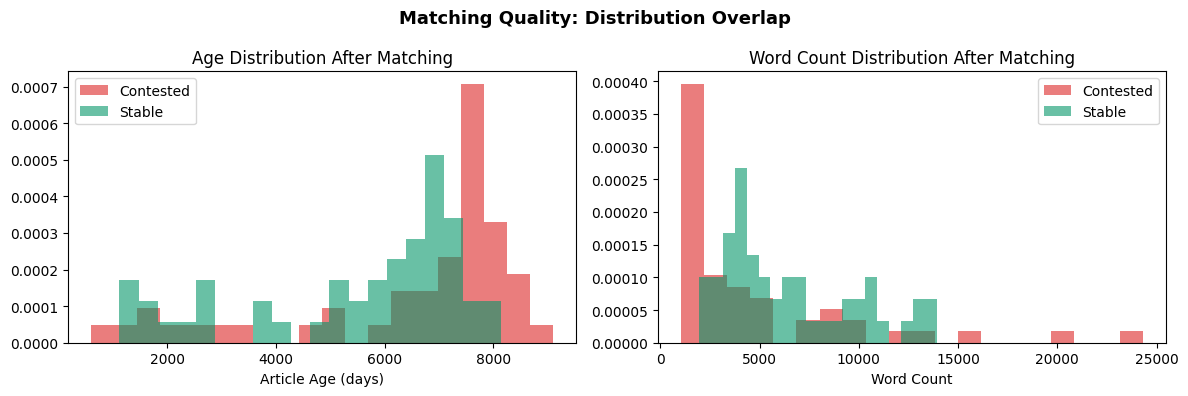


Age   — Contested: 6494 days | Stable: 5477 days
Words — Contested: 4574   | Stable: 6529


In [13]:
# ── Show first 10 pairs ───────────────────────────────────────────
print(f"{'CONTESTED':<35} {'STABLE':<35} {'DIST':>6}  TOPIC")
print("-" * 85)
for p in matched_pairs[:10]:
    c, s = p["contested"], p["stable"]
    topic_flag = "✅" if p["same_topic"] else "⚠️ "
    print(f"{c['title'][:33]:<35} {s['title'][:33]:<35} "
          f"{p['match_distance']:>6.4f}  {topic_flag} {c['topic']} → {s['topic']}")

# ── Distribution comparison ───────────────────────────────────────
c_ages  = [p["contested"]["age_days"]   for p in matched_pairs]
s_ages  = [p["stable"]["age_days"]      for p in matched_pairs]
c_words = [p["contested"]["word_count"] for p in matched_pairs]
s_words = [p["stable"]["word_count"]    for p in matched_pairs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Matching Quality: Distribution Overlap", fontsize=13, fontweight='bold')

axes[0].hist(c_ages, bins=20, alpha=0.6, color='#DC2626', label='Contested', density=True)
axes[0].hist(s_ages, bins=20, alpha=0.6, color='#059669', label='Stable', density=True)
axes[0].set_xlabel("Article Age (days)")
axes[0].set_title("Age Distribution After Matching")
axes[0].legend()

axes[1].hist(c_words, bins=20, alpha=0.6, color='#DC2626', label='Contested', density=True)
axes[1].hist(s_words, bins=20, alpha=0.6, color='#059669', label='Stable', density=True)
axes[1].set_xlabel("Word Count")
axes[1].set_title("Word Count Distribution After Matching")
axes[1].legend()

plt.tight_layout()
plt.savefig("matching_quality.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAge   — Contested: {np.mean(c_ages):.0f} days | Stable: {np.mean(s_ages):.0f} days")
print(f"Words — Contested: {np.mean(c_words):.0f}   | Stable: {np.mean(s_words):.0f}")


## 6. Feature Extraction

Extract linguistic + structural features from matched pairs.
Each feature has a clear hypothesis explaining why we expect it to differ.

| Feature | Hypothesis |
|---|---|
| **Hedging density** | Contested articles hedge more — facts are disputed | 
| **Causal connective density** | Stable articles explain causally — contested assert | 
| **Definition sentence ratio** | Stable articles define clearly — contested describe ambiguously |
| **Lexical diversity (MTLD)** | Stable cover topics broadly — contested circle disputed claims |
| **Citation count** | Stable articles are better sourced |
| **Section count** | Stable articles have more developed structure |
| **Edit recency ratio** | Contested have more recent activity — active disputes |


In [14]:
# ── Word lists ────────────────────────────────────────────────────
HEDGING_WORDS = [
    "allegedly", "apparently", "arguably", "claims", "claimed",
    "reportedly", "supposedly", "some argue", "some suggest",
    "it is claimed", "it has been argued", "according to some",
    "disputed", "controversial", "contentious", "debated",
    "critics say", "critics argue", "opponents claim",
    "proponents argue", "others believe", "many believe",
]

CAUSAL_WORDS = [
    "because", "therefore", "thus", "hence", "consequently",
    "as a result", "due to", "owing to", "since", "leads to",
    "caused by", "results in", "this explains", "for this reason",
    "accordingly", "which means", "resulting in",
]

DEFINITION_PATTERNS = [
    r'\bis (a|an|the)\b',
    r'\brefers to\b',
    r'\bdefined as\b',
    r'\bknown as\b',
    r'\bdescribed as\b',
    r'\bconsidered (a|an|the)\b',
]

def extract_features(article):
    """Extract all features from one article. Returns a flat dict."""
    text  = article.get("clean_text", "")
    words = text.lower().split()
    n     = len(words)
    if n == 0:
        return None
    
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    n_sent = max(len(sentences), 1)
    text_lower = text.lower()
    
    # ── Hedging density ─────────────────────────────────────
    hedge_count = sum(text_lower.count(w) for w in HEDGING_WORDS)
    hedging_density = round(hedge_count / n * 1000, 4)  # per 1000 tokens
    
    # ── Causal connective density ────────────────────────────
    causal_count = sum(text_lower.count(w) for w in CAUSAL_WORDS)
    causal_density = round(causal_count / n * 1000, 4)
    
    # ── Definition sentence ratio ────────────────────────────
    def_sents = sum(
        1 for s in sentences
        if any(re.search(p, s, re.IGNORECASE) for p in DEFINITION_PATTERNS)
    )
    def_ratio = round(def_sents / n_sent, 4)
    
    # ── Lexical diversity (MTLD) ─────────────────────────────
    mtld = None
    if LEXRICH_AVAILABLE and n >= 100:
        try:
            lex = LexicalRichness(text)
            mtld = round(lex.mtld(threshold=0.72), 4)
        except Exception:
            mtld = None
    if mtld is None:
        # Fallback: type-token ratio on first 200 words
        sample = words[:200]
        mtld = round(len(set(sample)) / len(sample), 4) if sample else None
    
    # ── Structural features ──────────────────────────────────
    return {
        "title":            article["title"],
        "label":            article["label"],
        "label_name":       article["label_name"],
        "topic":            article["topic"],
        # Linguistic
        "hedging_density":  hedging_density,
        "causal_density":   causal_density,
        "def_ratio":        def_ratio,
        "mtld":             mtld,
        # Structural
        "word_count":       article.get("word_count", n),
        "citation_count":   article.get("citation_count", 0),
        "section_count":    article.get("section_count", 0),
        "unique_editors":   article.get("unique_editors", 0),
        "age_days":         article.get("age_days", 0),
        "recency_ratio":    article.get("recency_ratio", 0),
        "trends_avg":       article.get("trends_avg"),
        # Talk page (validation only)
        "revert_count":     article.get("revert_count", 0),
        "talk_words":       article.get("talk_words", 0),
        "talk_editors":     article.get("talk_editors", 0),
    }

print("✅ Feature extraction functions defined")


✅ Feature extraction functions defined


In [15]:
# ── Extract features from all matched pairs ───────────────────────
records = []
for pair in matched_pairs:
    c_feat = extract_features(pair["contested"])
    s_feat = extract_features(pair["stable"])
    if c_feat and s_feat:
        records.append(c_feat)
        records.append(s_feat)

df = pd.DataFrame(records)
df.to_csv("pilot_features.csv", index=False)

print(f"✅ Feature matrix: {df.shape[0]} articles × {df.shape[1]} columns")
print(f"   Contested: {(df.label==0).sum()} | Stable: {(df.label==1).sum()}")
df.head(6)


✅ Feature matrix: 100 articles × 18 columns
   Contested: 50 | Stable: 50


,title,label,label_name,topic,hedging_density,causal_density,def_ratio,mtld,word_count,citation_count,section_count,unique_editors,age_days,recency_ratio,trends_avg,revert_count,talk_words,talk_editors
0,Hofbräuhaus am Platzl,0,contested,culture,3.0303,0.0000,0.0250,64.6667,1110,10,7,123,7676,0.005,13844,0,239,15
1,1982 Formula One World Championship,1,stable,culture,0.2248,2.0234,0.0000,15.8265,13918,76,28,156,2717,0.090,13896,0,737,26
2,WHU – Otto Beisheim School of Management,0,contested,culture,0.0000,0.0000,0.1000,37.6581,1211,30,9,211,6658,0.002,2625,0,1329,15
3,Antlia,1,stable,culture,0.0000,1.5117,0.2469,66.5512,3995,71,11,180,6814,0.018,2670,1,616,17
4,Matías Ramón Mella,0,contested,politics,1.0910,2.8366,0.0293,68.6896,9328,66,24,211,1142,0.166,1959,0,399,11
5,Black Christian Siriano gown of Billy Porter,1,stable,politics,0.6734,0.6734,0.0476,102.7611,3710,74,6,49,1549,0.000,1804,4,598,19


## 7. Exploratory Analysis — Do Features Already Differ?

In [16]:
FEATURE_COLS = [
    "hedging_density", "causal_density", "def_ratio", "mtld",
    "citation_count", "section_count", "recency_ratio"
]
FEATURE_LABELS = {
    "hedging_density": "Hedging Density",
    "causal_density":  "Causal Connectives",
    "def_ratio":       "Definition Ratio",
    "mtld":            "Lexical Diversity (MTLD)",
    "citation_count":  "Citation Count",
    "section_count":   "Section Count",
    "recency_ratio":   "Edit Recency Ratio",
}

contested_df = df[df.label == 0]
stable_df    = df[df.label == 1]

print("Feature means — Contested vs Stable:\n")
print(f"{'Feature':<25} {'Contested':>12} {'Stable':>12} {'Diff %':>8}")
print("-" * 60)
for col in FEATURE_COLS:
    c_mean = contested_df[col].mean()
    s_mean = stable_df[col].mean()
    diff   = ((c_mean - s_mean) / (s_mean + 1e-9)) * 100
    direction = "↑" if diff > 0 else "↓"
    print(f"{FEATURE_LABELS[col]:<25} {c_mean:>12.3f} {s_mean:>12.3f} "
          f"{direction}{abs(diff):>6.1f}%")


Feature means — Contested vs Stable:

Feature                      Contested       Stable   Diff %
------------------------------------------------------------
Hedging Density                  0.646        0.319 ↑ 102.2%
Causal Connectives               2.093        2.084 ↑   0.4%
Definition Ratio                 0.041        0.029 ↑  39.7%
Lexical Diversity (MTLD)        73.890       72.516 ↑   1.9%
Citation Count                  64.520       88.180 ↓  26.8%
Section Count                   15.260       14.980 ↑   1.9%
Edit Recency Ratio               0.040        0.024 ↑  65.8%


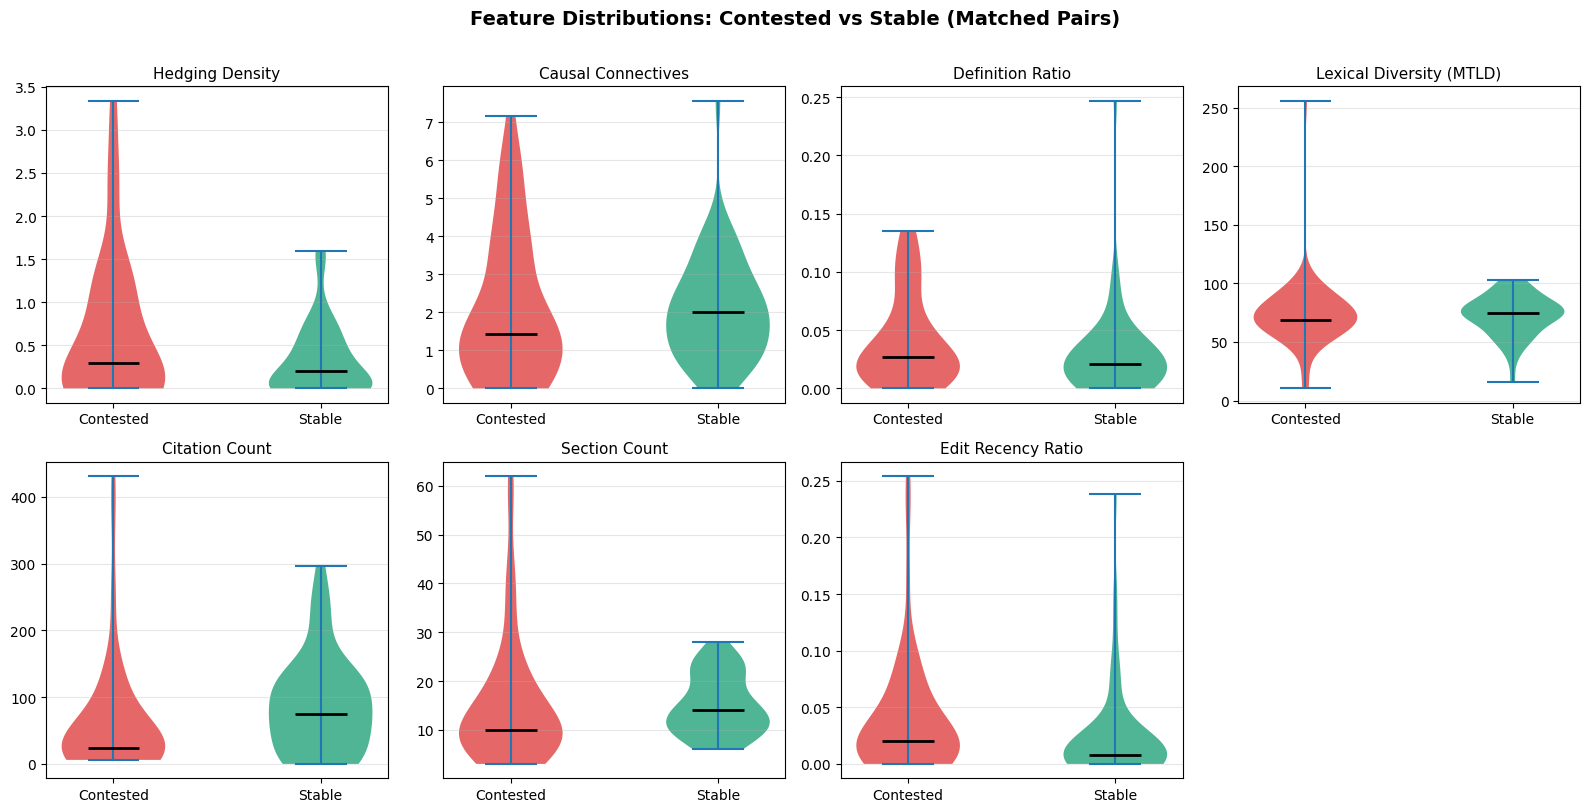

In [17]:
# ── Violin plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Feature Distributions: Contested vs Stable (Matched Pairs)",
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

colors = {'contested': '#DC2626', 'stable': '#059669'}

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    plot_data = [
        contested_df[col].dropna().values,
        stable_df[col].dropna().values
    ]
    parts = ax.violinplot(plot_data, positions=[0, 1],
                          showmedians=True, showextrema=True)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(list(colors.values())[j])
        pc.set_alpha(0.7)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Contested', 'Stable'])
    ax.set_title(FEATURE_LABELS[col], fontsize=11)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)  # hide empty subplot
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. Statistical Tests — Mann-Whitney U

Non-parametric test for each feature. Also used for Talk Page validation.

In [18]:
from scipy.stats import mannwhitneyu

print("Mann-Whitney U Tests (one-sided: does contested > or < stable?)\n")
print(f"{'Feature':<25} {'U-stat':>10} {'p-value':>10} {'Effect r':>10}  Direction  Sig?")
print("-" * 75)

results = []
for col in FEATURE_COLS + ["revert_count", "talk_words", "talk_editors"]:
    c_vals = contested_df[col].dropna().values
    s_vals = stable_df[col].dropna().values
    if len(c_vals) < 3 or len(s_vals) < 3:
        continue
    
    u_stat, p_val = mannwhitneyu(c_vals, s_vals, alternative='two-sided')
    n = len(c_vals) + len(s_vals)
    # Effect size r = Z / sqrt(N)
    from scipy.stats import norm
    z = norm.ppf(1 - p_val/2)
    effect_r = abs(z) / np.sqrt(n)
    
    direction = "C > S" if c_vals.mean() > s_vals.mean() else "C < S"
    sig = "✅" if p_val < 0.05 else ("~" if p_val < 0.1 else "❌")
    label = FEATURE_LABELS.get(col, col)
    
    print(f"{label:<25} {u_stat:>10.1f} {p_val:>10.4f} {effect_r:>10.3f}  "
          f"{direction}      {sig}")
    results.append({"feature": col, "p_value": p_val,
                    "effect_r": effect_r, "direction": direction, "sig": p_val < 0.05})

print("\n✅ = p < 0.05  ~ = p < 0.10  ❌ = not significant")
print("\nTalk Page signals (revert_count, talk_words, talk_editors) — validation only.")
print("If they show C > S with p < 0.05, our labels are valid.")


Mann-Whitney U Tests (one-sided: does contested > or < stable?)

Feature                       U-stat    p-value   Effect r  Direction  Sig?
---------------------------------------------------------------------------
Hedging Density               1439.0     0.1729      0.136  C > S      ❌
Causal Connectives            1140.0     0.4500      0.076  C > S      ❌
Definition Ratio              1480.5     0.1123      0.159  C > S      ❌
Lexical Diversity (MTLD)      1134.0     0.4259      0.080  C > S      ❌
Citation Count                 949.0     0.0382      0.207  C < S      ✅
Section Count                  965.5     0.0498      0.196  C > S      ✅
Edit Recency Ratio            1650.0     0.0058      0.276  C > S      ✅
revert_count                  1049.0     0.1000      0.165  C < S      ~
talk_words                    1099.5     0.3011      0.103  C < S      ❌
talk_editors                   931.0     0.0279      0.220  C < S      ✅

✅ = p < 0.05  ~ = p < 0.10  ❌ = not significant

Tal

## 9. Logistic Regression — Can Features Distinguish Contested from Stable?

In [19]:
FEATURE_COLS_MODEL = [
    "hedging_density", "causal_density", "def_ratio", "mtld",
    "citation_count", "section_count", "recency_ratio"
]

df_model = df[FEATURE_COLS_MODEL + ["label"]].dropna()
X = df_model[FEATURE_COLS_MODEL].values
y = df_model["label"].values

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 5-fold cross-validation ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

f1_scores  = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1_macro')
acc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')

print("5-fold Cross-Validation Results")
print(f"  F1 (macro):  {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
print(f"  Accuracy:    {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")

baseline = max(y.mean(), 1 - y.mean())
print(f"  Majority-class baseline: {baseline:.3f}")
print(f"  Improvement over baseline: {acc_scores.mean() - baseline:+.3f}")


5-fold Cross-Validation Results
  F1 (macro):  0.676 ± 0.099
  Accuracy:    0.680 ± 0.098
  Majority-class baseline: 0.500
  Improvement over baseline: +0.180


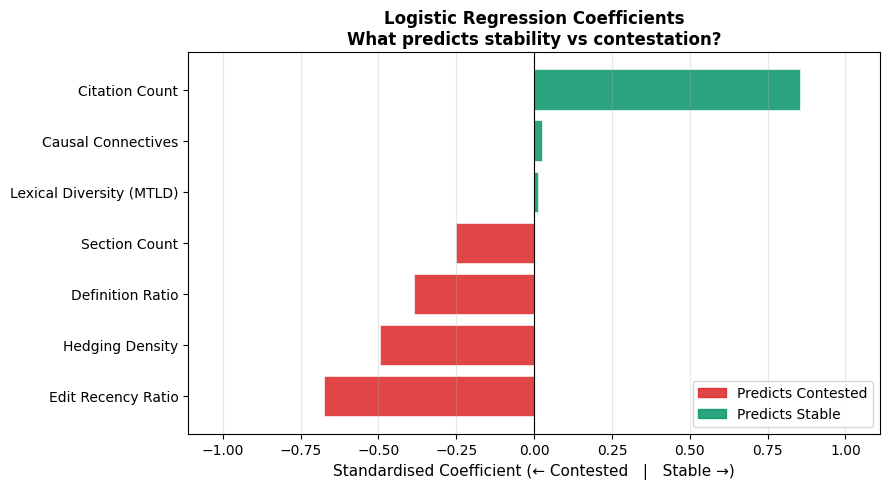


Coefficients (standardised):
  Edit Recency Ratio             -0.6757  ← → Contested
  Hedging Density                -0.4962  ← → Contested
  Definition Ratio               -0.3870  ← → Contested
  Section Count                  -0.2513  ← → Contested
  Lexical Diversity (MTLD)       +0.0123  → → Stable
  Causal Connectives             +0.0243  → → Stable
  Citation Count                 +0.8545  → → Stable


In [20]:
# ── Train on full pilot data + plot coefficients ──────────────────
model.fit(X_scaled, y)
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "feature":     [FEATURE_LABELS[f] for f in FEATURE_COLS_MODEL],
    "coefficient": coefficients,
    "direction":   ["→ Stable" if c > 0 else "→ Contested" for c in coefficients]
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#DC2626' if c < 0 else '#059669' for c in coef_df["coefficient"]]
bars = ax.barh(coef_df["feature"], coef_df["coefficient"],
               color=colors_bar, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel("Standardised Coefficient (← Contested   |   Stable →)", fontsize=11)
ax.set_title("Logistic Regression Coefficients\nWhat predicts stability vs contestation?",
             fontsize=12, fontweight='bold')

contested_patch = mpatches.Patch(color='#DC2626', alpha=0.85, label='Predicts Contested')
stable_patch    = mpatches.Patch(color='#059669', alpha=0.85, label='Predicts Stable')
ax.legend(handles=[contested_patch, stable_patch], loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-max(abs(coef_df["coefficient"]))*1.3,
             max(abs(coef_df["coefficient"]))*1.3)

plt.tight_layout()
plt.savefig("logistic_regression_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nCoefficients (standardised):")
for _, row in coef_df.iterrows():
    arrow = "←" if row["coefficient"] < 0 else "→"
    print(f"  {row['feature']:<30} {row['coefficient']:>+7.4f}  {arrow} {row['direction']}")


## 10. Pilot Summary & What We Learned

In [21]:
print("=" * 65)
print("PILOT STUDY SUMMARY")
print("=" * 65)
print(f"\n📊 Dataset")
print(f"   Contested articles:   {(df.label==0).sum()}")
print(f"   Stable articles:      {(df.label==1).sum()}")
print(f"   Same-topic pairs:     {same_topic}/{len(matched_pairs)}")
print(f"   Avg match distance:   {avg_dist:.4f}")

print(f"\n📈 Model Performance (5-fold CV)")
print(f"   F1 macro:    {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
print(f"   Accuracy:    {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"   Baseline:    {baseline:.3f}")

print(f"\n🔍 Key Feature Findings")
sig_results = [r for r in results if r["sig"] and r["feature"] in FEATURE_COLS_MODEL]
for r in sorted(sig_results, key=lambda x: x["effect_r"], reverse=True):
    label = FEATURE_LABELS.get(r["feature"], r["feature"])
    print(f"   ✅ {label:<28} effect r={r['effect_r']:.3f}  {r['direction']}")

insig = [r for r in results if not r["sig"] and r["feature"] in FEATURE_COLS_MODEL]
if insig:
    print(f"\n⚠️  Weak/non-significant features (consider dropping):")
    for r in insig:
        label = FEATURE_LABELS.get(r["feature"], r["feature"])
        print(f"   ❌ {label:<28} p={r['p_value']:.3f}")

print(f"\n✅ Talk Page Validation")
talk_results = [r for r in results if r["feature"] in ["revert_count","talk_words","talk_editors"]]
for r in talk_results:
    label = r["feature"]
    status = "✅ VALID" if r["sig"] and "C > S" in r["direction"] else "⚠️  CHECK"
    print(f"   {status}  {label:<20} p={r['p_value']:.3f}  {r['direction']}")

print(f"\n🚀 Next Steps")
print("   1. If F1 > 0.60 → features are working → scale to 200 per group")
print("   2. If same-topic match rate < 60% → collect more stable candidates")
print("   3. Drop features with p > 0.10 and effect r < 0.15")
print("   4. Replicate full pipeline for German (DE)")
print("   5. Cross-lingual coefficient comparison = your main finding")
print("=" * 65)


PILOT STUDY SUMMARY

📊 Dataset
   Contested articles:   50
   Stable articles:      50
   Same-topic pairs:     45/50
   Avg match distance:   5.3875

📈 Model Performance (5-fold CV)
   F1 macro:    0.676 ± 0.099
   Accuracy:    0.680 ± 0.098
   Baseline:    0.500

🔍 Key Feature Findings
   ✅ Edit Recency Ratio           effect r=0.276  C > S
   ✅ Citation Count               effect r=0.207  C < S
   ✅ Section Count                effect r=0.196  C > S

⚠️  Weak/non-significant features (consider dropping):
   ❌ Hedging Density              p=0.173
   ❌ Causal Connectives           p=0.450
   ❌ Definition Ratio             p=0.112
   ❌ Lexical Diversity (MTLD)     p=0.426

✅ Talk Page Validation
   ⚠️  CHECK  revert_count         p=0.100  C < S
   ⚠️  CHECK  talk_words           p=0.301  C < S
   ⚠️  CHECK  talk_editors         p=0.028  C < S

🚀 Next Steps
   1. If F1 > 0.60 → features are working → scale to 200 per group
   2. If same-topic match rate < 60% → collect more stable candi

---

## Files Generated

| File | Contents |
|---|---|
| `pilot_contested.json` | Raw contested articles (50) |
| `pilot_stable_pool.json` | Raw stable pool (300 candidates) |
| `pilot_matched_pairs.json` | Matched pairs with metadata |
| `pilot_features.csv` | Feature matrix — ready for modelling |
| `matching_quality.png` | Age + word count distributions after matching |
| `feature_distributions.png` | Violin plots per feature |
| `logistic_regression_coefficients.png` | Coefficient bar chart |

## How to interpret results

**If F1 macro > 0.65:** Features are discriminating well. The design works — scale up.  
**If F1 macro 0.55–0.65:** Moderate signal. Add more features or refine matching.  
**If F1 macro < 0.55:** Near-baseline. Either matching is too loose, features need revision, or pilot sample is too small.

**Talk Page validation:** If `revert_count` and `talk_words` show p < 0.05 with Contested > Stable — your labels are confirmed valid and this should go in the paper as construct validity evidence.
